<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/AUTOENCODERS_DATASET_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.layers import Dense, Input, Dropout
from keras.models import Model
from keras.models import Sequential



In [ ]:
# Carregando o conjunto de dados do MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)
valMax = x_train.max()
print(valMax)
valMin = x_train.min()
print(valMin)


# Normalizando os valores dos pixels para o intervalo [0, 1]
x_train = x_train / valMax
x_test = x_test / valMax


# Transformando as imagens em vetores unidimensionais (784 pixels)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)


(60000, 28, 28)
(60000,)
255
0
(60000, 784)
(10000, 784)


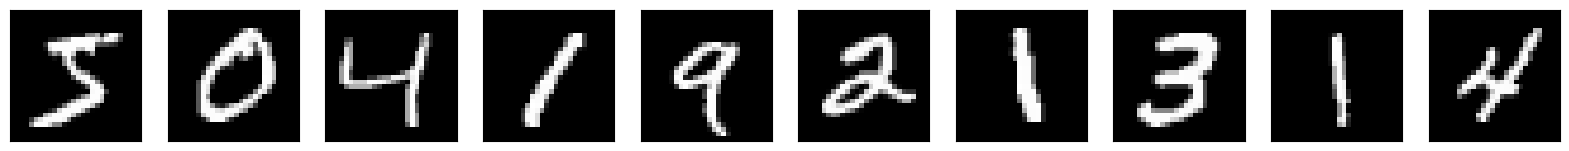

In [ ]:
# Visualizando algumas imagens originais
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagem de entrada com ruído
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

(60000, 784)
(10000, 784)


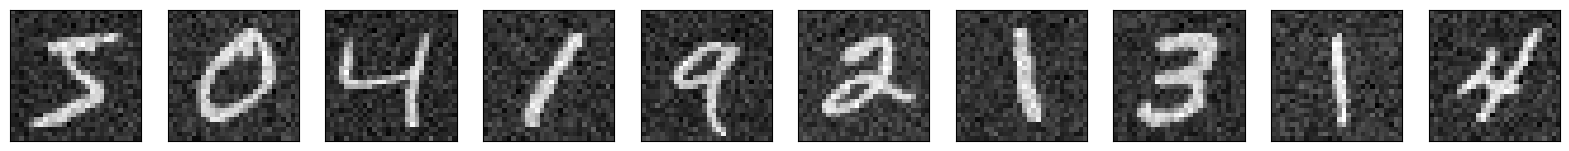

In [ ]:
# Aplicação de ruído nos dados e armazenando em variáveis acessórias
factor = 0.1
x_train_noisy = x_train + factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

print(x_train_noisy.shape)
print(x_test_noisy.shape)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagem de entrada com ruído
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
# CONSTRUÇÃO DO MODELO AUTOENCODER COM DADOS ORIGINAIS
# Definindo a dimensão da representação codificada
n_latent = 60
dimInput = x_train.shape[1]

# Criando o modelo do autoencoder
model = Sequential()
model.add(Dense(units = 400, input_dim = dimInput, activation="relu"))
model.add(Dense(units = 200, activation="relu"))
model.add(Dense(units = n_latent, activation="relu"))
model.add(Dense(units = 200, activation="relu"))
model.add(Dense(units = 400, activation="relu"))
model.add(Dense(units = dimInput, activation="sigmoid"))

# Compilando o modelo
model.compile(optimizer='adam', loss='binary_crossentropy')

# Codificando e decodificando as imagens de teste sem ruído
encoded_imgs = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Treinando o autoencoder
model.fit(x_train, x_train, epochs=30, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# Testando e decodificando as imagens de teste sem ruído
encoded_imgs = encoder.predict(x_test)


Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.1994 - val_loss: 0.1239
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.1128 - val_loss: 0.1031
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0998 - val_loss: 0.0956
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0937 - val_loss: 0.0902
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0898 - val_loss: 0.0877
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0871 - val_loss: 0.0855
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0850 - val_loss: 0.0845
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.0834 - val_loss: 0.0822
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0820 - val_loss: 0.0812
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0808 - val_loss: 0.0797
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0798 - val_loss: 0.0791
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━

NameError: name 'encoder' is not defined

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


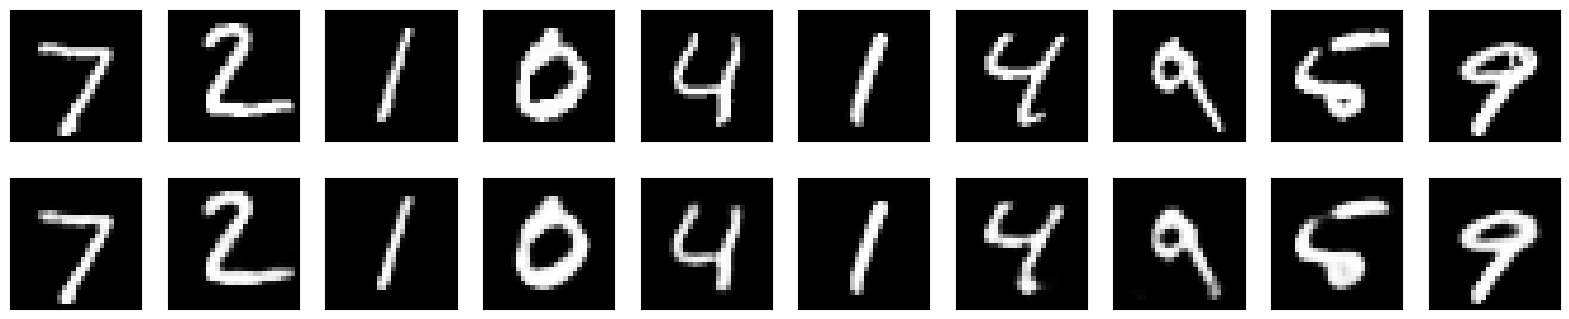

In [ ]:
# Obter imagens reconstruídas
decoded_imgs = model.predict(x_test)
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Imagem original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagem reconstruída
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()



In [ ]:
# Codificando e decodificando as imagens de teste com ruído
encoded_imgs = model.predict(x_test_noisy)




313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


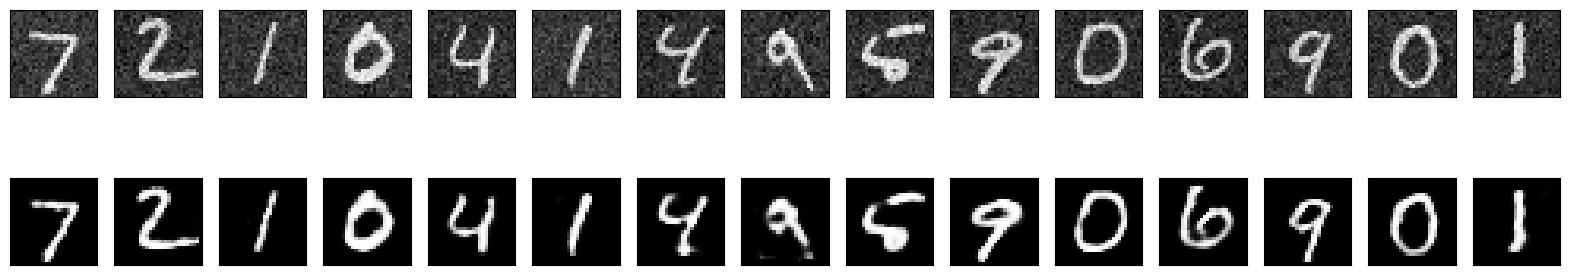

In [ ]:
# Visualizando algumas imagens originais com ruído e reconstruídas
n = 15
plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagem de entrada com ruído
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagem reconstruída com redução do ruído
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
# Criando um Modelo de Classificação para testar as amostras ruidosas, amostras originais e as amostras recuperadas do ruído
num_labels = len(np.unique(y_train))

model2 = Sequential()

model2.add(Dense(units=400, input_dim=x_train.shape[1], activation='relu'))
#model2.add(Dropout(dropout)) # Esta camada ajuda a evitar overfitting durante o treinamento, desligando aleatoriamente um certo número de neurônios

model2.add(Dense(units=100, activation='relu'))
#model2.add(Dropout(dropout))

model2.add(Dense(units=num_labels, activation='softmax'))

model2.compile(loss='sparse_categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.fit(x_train, y_train, epochs=40, batch_size=256)

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9142 - loss: 0.3063
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9664 - loss: 0.1129
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9779 - loss: 0.0743
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9850 - loss: 0.0516
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9888 - loss: 0.0372
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9913 - loss: 0.0296
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9942 - loss: 0.0207
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9959 - loss: 0.0158
Epoch 9/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9965 - loss: 0.0129
Epoch 10/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9963 - loss: 0.0124
Epoch 11/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9969 - loss: 0.0102
Epoch 12/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
loss, acc = model2.evaluate(x_test, y_test)
print("\nTeste de Acurácia Classificação sem Ruído: %.1f%%" % (100.0 * acc))
loss, acc = model2.evaluate(x_test_noisy, y_test)
print("\nTeste de Acurácia Classificação com Ruído: %.1f%%" % (100.0 * acc))
loss, acc = model2.evaluate(encoded_imgs, y_test)
print("\nTeste de Acurácia Classificação das Imagens Recuperadas do Ruído: %.1f%%" % (100.0 * acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9835 - loss: 0.0924

Teste de Acurácia Classificação sem Ruído: 98.4%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9803 - loss: 0.1170

Teste de Acurácia Classificação com Ruído: 98.0%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.1250

Teste de Acurácia Classificação das Imagens Recuperadas do Ruído: 97.8%


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report, mean_squared_error, ConfusionMatrixDisplay
y_pred = model2.predict(x_test)
# Converter as previsões para classes
y_pred = np.argmax(y_pred, axis=1)

print("Avaliação da Classificação")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print(f"Matriz de confusão das amostras não apresentadas no treinamento:\n {confusion_matrix(y_test, y_pred)}")
print("")
relatório = classification_report(y_test, y_pred, target_names=["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"])
print("Relatório de classificação das amostras não apresentadas no treinamento:")
print(relatório)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Avaliação da Classificação
Acurácia: 0.9835
MSE:  0.292
Matriz de confusão das amostras não apresentadas no treinamento:
 [[ 971    0    1    0    1    2    2    1    2    0]
 [   0 1126    3    0    0    0    2    1    3    0]
 [   4    1 1013    3    1    0    2    3    5    0]
 [   0    0    3  995    0    3    0    2    4    3]
 [   2    1    3    1  964    0    2    3    1    5]
 [   2    0    0    6    1  872    4    1    5    1]
 [   3    3    1    1    3    3  944    0    0    0]
 [   1    2    4    1    0    1    0 1011    2    6]
 [   2    1    5    1    1    1    4    4  952    3]
 [   1    2    0    2    7    2    0    3    5  987]]

Relatório de classificação das amostras não apresentadas no treinamento:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3   

Matrix de confusão das amostras não apresentadas no treinamento:
 [[ 971    0    1    0    1    2    2    1    2    0]
 [   0 1126    3    0    0    0    2    1    3    0]
 [   4    1 1013    3    1    0    2    3    5    0]
 [   0    0    3  995    0    3    0    2    4    3]
 [   2    1    3    1  964    0    2    3    1    5]
 [   2    0    0    6    1  872    4    1    5    1]
 [   3    3    1    1    3    3  944    0    0    0]
 [   1    2    4    1    0    1    0 1011    2    6]
 [   2    1    5    1    1    1    4    4  952    3]
 [   1    2    0    2    7    2    0    3    5  987]]



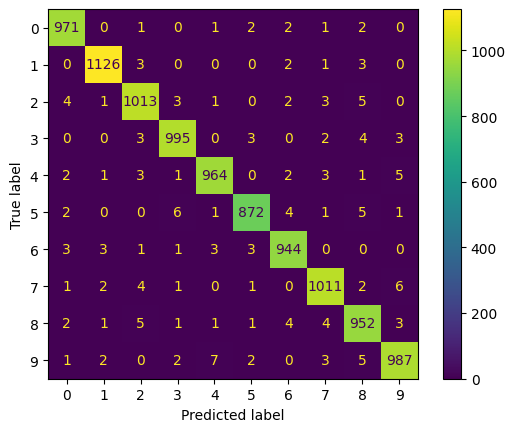

In [ ]:
print(f"Matrix de confusão das amostras não apresentadas no treinamento:\n {confusion_matrix(y_test, y_pred)}")
print("")
conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"])
cm_display.plot()
plt.show()